In [1]:
path_to_data = "./dataset/"
path_to_cr_data = "./cropped/"

In [2]:
import os
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)

In [3]:
img_dirs

['./dataset/Atif_Aslam',
 './dataset/Bhola_Record',
 './dataset/Humayun_Saeed',
 './dataset/Imran_Khan',
 './dataset/Waqar_Zaqa']

In [4]:
import cv2
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')


In [5]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color

In [6]:
image = './dataset/Bhola_Record/000002.jpg'
img = cv2.imread(image,)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.3, 5)


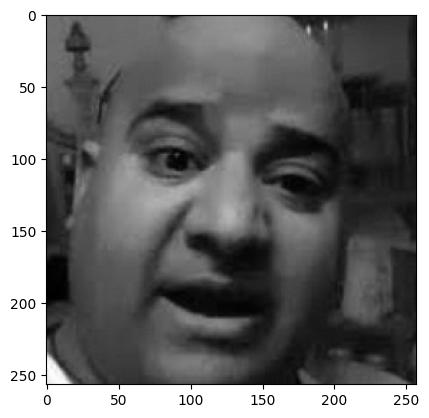

In [7]:
import matplotlib.pyplot as plt
for (x,y,w,h) in faces:
    roi_gray = gray[y:y+h, x:x+w]
    plt.imshow(roi_gray, cmap='gray')

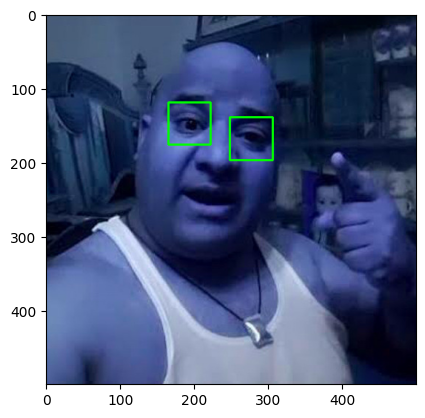

In [14]:
eyes = eye_cascade.detectMultiScale(gray)
for (ex,ey,ew,eh) in eyes:
    cv2.rectangle(img, (ex,ey), (ex+ew,ey+eh),color=(0, 255, 0), thickness=2)
    plt.imshow(img)

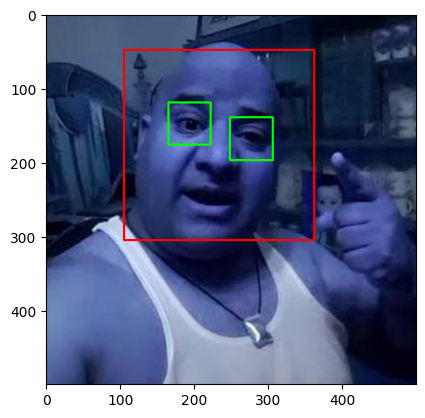

In [16]:
for (x,y,w,h) in faces:
    cv2.rectangle(img, (x,y), (x+w,y+h), color=(255, 0, 0), thickness=2)
    plt.imshow(img)

In [ ]:
import shutil
if os.path.exists(path_to_cr_data):
     shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [17]:
cropped_image_dirs = []
celebrity_file_names_dict = {}
for img_dir in img_dirs:
    count = 1
    celebrity_name = img_dir.split('/')[-1]
    celebrity_file_names_dict[celebrity_name] = []
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data + celebrity_name
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ",cropped_folder)
            cropped_file_name = celebrity_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name
            cv2.imwrite(cropped_file_path, roi_color)
            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count += 1

Generating cropped images in folder:  ./cropped/Atif_Aslam
Generating cropped images in folder:  ./cropped/Bhola_Record
Generating cropped images in folder:  ./cropped/Humayun_Saeed
Generating cropped images in folder:  ./cropped/Imran_Khan
Generating cropped images in folder:  ./cropped/Waqar_Zaqa


[['./cropped/Atif_Aslam/Atif_Aslam1.png',
  './cropped/Atif_Aslam/Atif_Aslam2.png',
  './cropped/Atif_Aslam/Atif_Aslam3.png',
  './cropped/Atif_Aslam/Atif_Aslam4.png',
  './cropped/Atif_Aslam/Atif_Aslam5.png',
  './cropped/Atif_Aslam/Atif_Aslam6.png',
  './cropped/Atif_Aslam/Atif_Aslam7.png',
  './cropped/Atif_Aslam/Atif_Aslam8.png',
  './cropped/Atif_Aslam/Atif_Aslam9.png',
  './cropped/Atif_Aslam/Atif_Aslam10.png',
  './cropped/Atif_Aslam/Atif_Aslam11.png',
  './cropped/Atif_Aslam/Atif_Aslam12.png',
  './cropped/Atif_Aslam/Atif_Aslam13.png',
  './cropped/Atif_Aslam/Atif_Aslam14.png',
  './cropped/Atif_Aslam/Atif_Aslam15.png',
  './cropped/Atif_Aslam/Atif_Aslam16.png',
  './cropped/Atif_Aslam/Atif_Aslam17.png',
  './cropped/Atif_Aslam/Atif_Aslam18.png',
  './cropped/Atif_Aslam/Atif_Aslam19.png',
  './cropped/Atif_Aslam/Atif_Aslam20.png',
  './cropped/Atif_Aslam/Atif_Aslam21.png',
  './cropped/Atif_Aslam/Atif_Aslam22.png',
  './cropped/Atif_Aslam/Atif_Aslam23.png',
  './cropped/Atif_As